<a href="https://colab.research.google.com/github/GabCAD92/Machine-learning-tasks/blob/main/Artificial_Neural_Networks_classwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning
## Supervised Learning: Artificial Neural Networks (ANNs)

This lesson introduces __Multilayer Perceptrons (MLPs)__ and __Backpropagation__ using __SKLearn__ applyied to a __Classification__ task.


### Professor:

<img src="https://www.sorocaba.unesp.br/Home/Graduacao/EngenhariadeControleeAutomacao/alexandre/alex_marta1_small.jpg" width="100" style="float: left; margin-right: 5px;" border="10px" />

  __Prof. Dr. Alexandre da Silva Simões__ <br>
  Department of Control and Automation Engineering (DECA) <br>
  Institute of Science and Technology of Sorocaba (ICTS) <br>
  São Paulo State University (Unesp) <br>
  www.sorocaba.unesp.br/professor/assimoes

<br/>

Based on:
* Géron, A. "Hands-On Machine Learning with Scikit-Learn and TensorFlow", O’Reilly Media Inc., Sebastopol, CA, EUA.
* Simões, A. S. Segmentação de imanges por classificação de cores: uma abordagem neural. Dissertação (mestrado). Escola Politécnica. Universidade de São Paulo. São Paulo, 2000.


# Table of Contents


1. The color classification problem <br>
    1.1 General overview <br>
    1.2. The RGB space <br>
    1.3. Classification goal <br>
 <br>
2. MLP in the classification task<br>
    2.1. Overview of the approach <br>
    2.2. Training with a small number of examples <br>
	2.3. Validation error <br>
    2.4. Increasing the number of examples <br>
    2.5. Adjusting input data distribution <br>
    2.6. Influence of the learning rate <br>
    2.7. Underfitting <br>
    2.8. Increasing the validation set<br>

____


## 1. The color classification problem

### 1.1 General overview

In robotics soccer, the players are identifyed by an image recognition program based on the colored circles in their "t-shirts".

<img src="https://drive.google.com/uc?id=1Vh4oXyB_pY7T6TsE9mDzvMoJqP0ii9xY" width="400" style="float: left; margin-right: 5px;" border="0px" />

In this way, it is necessary to develop a sofwtare that is cappable to classify the colors of the pixels to transform this input image:


<img src="https://drive.google.com/uc?id=1p7xtBHW0JQNLx7B83VB0rpy1L53X1cZV" width="400" style="float: left; margin-right: 5px;" border="0px" />

in an output image like this:

<img src="https://drive.google.com/uc?id=17XuNGh_6kXwAzm_jbFKaV2TZDZT4brKU" width="400" style="float: left; margin-right: 5px;" border="0px" />



### 1.2. The RGB space

This problem can be seen as a pixel classification under $R^3$ if we consider the RGB space:
        

In [1]:
# Importing the dataset...
from google.colab import drive
drive.mount('/content/drive/')
path = '/content/drive/My Drive/Colab Notebooks/input_image.jpg'
path_dat = '/content/drive/My Drive/Colab Notebooks/input_image.dat'

Mounted at /content/drive/


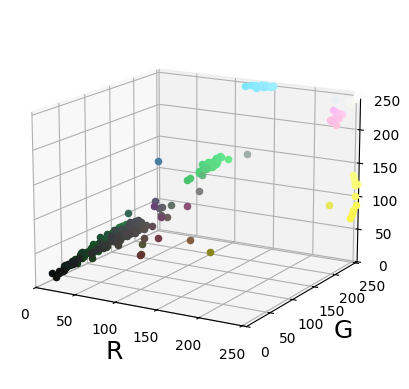

In [2]:
# Creating the RGB space viewer...

def plot_RGB(my_path, STEP):
    # ----------------------------------------
    # Plot the input_image in RGB color space
    # plotting one in each STEP pixels for a
    # faster plot
    # ----------------------------------------
    #%matplotlib widget
    from PIL import Image
    import numpy as np
    from mpl_toolkits.mplot3d import Axes3D
    import matplotlib.pyplot as plt

    f = open(my_path, 'rb')

    img = Image.open(f)
    width, height = img.size
    myarray = np.array(img)

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    for h in range (0,height-1, STEP):
        for w in range (0, width-1, STEP):
            x, y, z = myarray[h][w]
            mycolor = '#'+str(format(x, '02x'))+str(format(y, '02x'))+str(format(z, '02x'))
            ax.scatter(x, y, z, color=mycolor)

    ax.set_xlabel('R', fontsize=18)
    ax.set_ylabel('G', fontsize=18)
    ax.set_zlabel('B', fontsize=18)
    ax.set_xlim(0,255)
    ax.set_ylim(0,255)
    ax.set_zlim(0,255)
    ax.view_init(azim=-60, elev=15)

    plt.show()

plot_RGB(path, 50)


### 1.3. Classification goal

Our goal is to classify pixels in this $R^3$ space:

<img src="https://drive.google.com/uc?id=1c7DZ9xFF4sC6hDlguh9O1Fue_zrZTDy6" width="400" style="float: left; margin-right: 5px;" border="0px" />

like this:

<img src="https://drive.google.com/uc?id=1c0rSiNzfdfyhRZ352SgmRhYcJ_8Y-oIv" width="400" style="float: left; margin-right: 5px;" border="0px" />

These classes cannot be splited using a IF-THEN structure... A more powerful classifier is required.


<img src="https://drive.google.com/uc?id=1mUQp1MGDWOq6NE2MHi_RdAdWw1RDfJ55" width="300" style="float: left; margin-right: 5px;" border="0px" />


## 2. Neural Network in the classification task

### 2.1. Overview of the approach

In this experiment we will adopt the following NN:

<img src="https://drive.google.com/uc?id=1q_3fgMCHh52_yJfajg-GxgFLARuqKrvU" width="500" style="float: left; margin-right: 5px;" border="0px" />



* __Network architecture__:
    * Input layer: 3 neurons (R, G, B of a pixel)
    * Hidden layers: 2 layers with a variable nunber of neurons (configured in each experiment)
    * Output layer: 5 neurons, one for each output class (_one of 5_ classes)
    * Activation function: _logistic_ funciton.
* __Traning__:
    * __Training set__: the 203.232 pixels of the __input image__ were manually classified by a human, that is, a label was manually assingned to each pixel. This data is available to use in the training process in the "input_image.dat" file (number x y R G B class). The number of pixels to be used in the training processes will be different in each experiment. The pixels available in each class are:
        * __bk__ (black): 163.452 pixels
        * __p__ (pink):    12.565 pixels
        * __y__ (yellow):   5.675 pixels
        * __g__ (green):   10.770 pixels
        * __b__ (blue):    10.770 pixels
        * __TOTAL__:      203.232 pixels in the image
    * __Learning rate__: the learning rate will be configured in each experiment;
    * __Validation__: the NN will automatically set aside a percentage of training data for validation (configured in each experiment). The typical value is 10%;
    * __Number of training steps__: The number of training steps will change in our experiments. Options are:
        * __Fixed number of steps__: The NN will typically train until a fixed number of steps is reached;
        * __Early stop__: The training will be terminated if:
            * The __training error__ did not improve more than some $δ$ for $n$ consecutive steps;
            * The __validation error__ did not improve more than some $δ$ for $n$ consecutive steps;
* After the training process, some images will be generated:
    * The evolution of the __training and validation error__;
    * The input image will be submited to the NN for classification. The __output image__ will be shown (a visual __test set__);
    * The __colorspace__ will be generated to show the generalization of the NN.
$ $
    

In [3]:
def NN(input_file, *args, **kwargs):

    # ----------------------------------------------
    # Implements an Artificial Neural Network (ANN)
    # Multilayer Perceptron (MLP) trained with the
    # error backpropagation algorithm to pixel color
    # classification in RGB space
    # Parameters:
    #    TRAINING_SET_BK: number of training examples of the BK class
    #    TRAINING_SET_P : number of training examples of the P class
    #    TRAINING_SET_Y : number of training examples of the Y class
    #    TRAINING_SET_G : number of training examples of the G class
    #    TRAINING_SET_B : number of training examples of the B class
    #    LEARNING_RATE  : Learning rate
    #    MAX_ITERATIONS : maximum number of iterations (training interruption)
    #    NUM_NEURONS_HIDDEN : Number of neurons in the hidden layer
    #    VALIDATION_FRACTION : Percentage of the total pixels used in the validation set
    #    VALIDATION_STOP : True/False (enable/disable early stop if validation does not change significantly for N_STEPS_STOP)
    #    N_STEPS_STOP : Number of training steps without significant change in training/validation error (default = 10)
    # ----------------------------------------------


    TRAINING_SET_BK = kwargs.get('TRAINING_SET_BK', 16345)
    TRAINING_SET_P = kwargs.get('TRAINING_SET_P', 1256)
    TRAINING_SET_Y = kwargs.get('TRAINING_SET_Y', 567)
    TRAINING_SET_G = kwargs.get('TRAINING_SET_G', 1077)
    TRAINING_SET_B = kwargs.get('TRAINING_SET_B', 1077)
    LEARNING_RATE = kwargs.get('LEARNING_RATE', 0.005)
    MAX_ITERATIONS = kwargs.get('MAX_ITERATIONS', 100000)
    NUM_NEURONS_HIDDEN = kwargs.get('NUM_NEURONS_HIDDEN', 20)
    VALIDATION_FRACTION = kwargs.get('VALIDATION_FRACTION', 0.1) # Float number between 0 (no validation set) and 1 (100% of the examples used in validation set)
    VALIDATION_STOP = kwargs.get('VALIDATION_STOP', True)
    N_STEPS_STOP = kwargs.get('N_STEPS_STOP', 10)

    from PIL import Image
    import numpy as np
    import random
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D
    from sklearn.neural_network import MLPClassifier
    import matplotlib.image as mpimg
    import random

    random.seed(42)
    EXAMPLES_VERBOSE            = False
    MLP_VERBOSE                 = True
    GENERATE_OUTPUT_IMAGE       = True
    OUTPUT_FILE                 = 'output_image.png'

    # --------------------------------------
    # Step 1. Load data from file
    # --------------------------------------

    file = open(input_file, 'r')
    text = file.readlines()
    numpixels = len(text)
    #print("Number of pixels:",numpixels)
    index = []
    x = []
    y = []
    r = []
    g = []
    b = []
    color = []

    for i in range(0, numpixels):
        tmp = text[i].split(' ')
        index.append(tmp[0])
        x.append(int(tmp[1]))
        y.append(int(tmp[2]))
        r.append(int(tmp[3]))
        g.append(int(tmp[4]))
        b.append(int(tmp[5]))
        tmp2 = tmp[6].split('\n')
        color.append(tmp2[0])

    # --------------------------------------
    # Step 2. Prepare lists for training and validation sets
    # --------------------------------------
    # Data is organized as follows:
    #      index[i]: the number of the ith pixel (from 0 to 203.232)
    #      x[i]: the x position of the pixel in the image (from 0 to width=464 pixels)
    #      y[i]: the y position of the pixel in the image (from 0 to height=438 pixels)
    #      r[i]: the Red value of the pixel (from 0 to 255)
    #      g[i]: the Green value of the pixel (from 0 to 255)
    #      b[i]: the Blue value of the pixel (from 0 to 255)
    #      color[i]: the color of the pixel according to the template.
    # --------------------------------------

    bk_examples_index = []
    p_examples_index = []
    y_examples_index = []
    g_examples_index = []
    b_examples_index = []

    # Get examples of each class
    for i in range (0, numpixels):
        if (color[i]=='bk'): bk_examples_index.append(i)
        elif (color[i]=='p'): p_examples_index.append(i)
        elif (color[i]=='y'): y_examples_index.append(i)
        elif (color[i]=='g'): g_examples_index.append(i)
        elif (color[i]=='b'): b_examples_index.append(i)

    # Choose examples of each class for the TRAINING set

    bk_training_index = random.sample(bk_examples_index , TRAINING_SET_BK)
    p_training_index = random.sample(p_examples_index , TRAINING_SET_P)
    y_training_index = random.sample(y_examples_index , TRAINING_SET_Y)
    g_training_index = random.sample(g_examples_index , TRAINING_SET_G)
    b_training_index = random.sample(b_examples_index , TRAINING_SET_B)

    # Preparing lists for TRAINING: X and Y

    X = []
    Y = []
    for i in range(0, len(bk_training_index)):
        X.append([int(r[bk_training_index[i]]), int(g[bk_training_index[i]]), int(b[bk_training_index[i]])])
        if (EXAMPLES_VERBOSE==True):
            if (i==0):
                print('Black examples ([1,0,0,0,0]):')
            print(int(r[bk_training_index[i]]), ' ', int(g[bk_training_index[i]]), ' ', int(b[bk_training_index[i]]))
        Y.append([1,0,0,0,0])

    for i in range(0, len(p_training_index)):
        X.append([int(r[p_training_index[i]]), int(g[p_training_index[i]]), int(b[p_training_index[i]])])
        if (EXAMPLES_VERBOSE==True):
            if (i==0):
                print('Pink examples ([0,1,0,0,0]):')
            print(int(r[p_training_index[i]]), ' ', int(g[p_training_index[i]]), ' ', int(b[p_training_index[i]]))
        Y.append([0,1,0,0,0])

    for i in range(0, len(y_training_index)):
        X.append([int(r[y_training_index[i]]), int(g[y_training_index[i]]), int(b[y_training_index[i]])])
        if (EXAMPLES_VERBOSE==True):
            if (i==0):
                print('Yellow examples ([0,0,1,0,0]):')
            print(int(r[y_training_index[i]]), ' ', int(g[y_training_index[i]]), ' ', int(b[y_training_index[i]]))
        Y.append([0,0,1,0,0])

    for i in range(0, len(g_training_index)):
        X.append([int(r[g_training_index[i]]), int(g[g_training_index[i]]), int(b[g_training_index[i]])])
        if (EXAMPLES_VERBOSE==True):
            if (i==0):
                print('Green examples ([0,0,0,1,0]):')
            print(int(r[g_training_index[i]]), ' ', int(g[g_training_index[i]]), ' ', int(b[g_training_index[i]]))
        Y.append([0,0,0,1,0])

    for i in range(0, len(b_training_index)):
        X.append([int(r[b_training_index[i]]), int(g[b_training_index[i]]), int(b[b_training_index[i]])])
        if (EXAMPLES_VERBOSE==True):
            if (i==0):
                print('Blue examples ([0,0,0,0,1]):')
            print(int(r[b_training_index[i]]), ' ', int(g[b_training_index[i]]), ' ', int(b[b_training_index[i]]))
        Y.append([0,0,0,0,1])

    # Prepare lists for PREDICTION: ALL, BK, PI, YE, GR, BL

    ALL = []
    for i in range(0, numpixels):
        ALL.append([int(r[i]), int(g[i]), int(b[i])])
    BK = []
    for i in range(0, len(bk_training_index)):
        BK.append([int(r[bk_training_index[i]]), int(g[bk_training_index[i]]), int(b[bk_training_index[i]])])
    PI = []
    for i in range(0, len(p_training_index)):
        PI.append([int(r[p_training_index[i]]), int(g[p_training_index[i]]), int(b[p_training_index[i]])])
    YE = []
    for i in range(0, len(y_training_index)):
        YE.append([int(r[y_training_index[i]]), int(g[y_training_index[i]]), int(b[y_training_index[i]])])
    GR = []
    for i in range(0, len(g_training_index)):
        GR.append([int(r[g_training_index[i]]), int(g[g_training_index[i]]), int(b[g_training_index[i]])])
    BL = []
    for i in range(0, len(b_training_index)):
        BL.append([int(r[b_training_index[i]]), int(g[b_training_index[i]]), int(b[b_training_index[i]])])


    # --------------------------------------
    # Step 3. ANN training
    # --------------------------------------
    # Lists for training:
    #   - X: input vector (training and validation examples)
    #   - Y: output vector (targets)
    # --------------------------------------

    # Create MLP
    MLP = MLPClassifier(activation='logistic', learning_rate='constant', learning_rate_init=LEARNING_RATE, max_iter=MAX_ITERATIONS, verbose=MLP_VERBOSE, validation_fraction=VALIDATION_FRACTION, hidden_layer_sizes=(NUM_NEURONS_HIDDEN, NUM_NEURONS_HIDDEN), early_stopping=VALIDATION_STOP, n_iter_no_change=N_STEPS_STOP)

    # Train MLP
    MLP.fit(X, Y)

    fig = plt.figure()
    #imgplot = plt.plot(MLP.estimator.loss_curve_)
    plt.ylabel('cost')
    plt.xlabel('iterations')
    plt.title("NN Training")
    plt.grid(True)
    plt.plot(MLP.loss_curve_, linewidth=4)
    if (VALIDATION_STOP):
        #hold(True)
        plt.plot(MLP.validation_scores_, linewidth=4)
        plt.legend(['Training error', 'Validation error'])
    plt.show()


    # --------------------------------------
    # Step 4. ANN predict
    # --------------------------------------
    # Avaliable input lists:
    #      X: list with selected examples
    #      BK: list with all black pixels
    #      PI: list with all pink pixels
    #      YE: list with all yellow pixels
    #      GR: list with all green pixels
    #      BL: list with all blue pixels
    #      ALL: list with all pixels
    # Available output list:
    #      Y: list of targets to X
    # --------------------------------------


    #O = []
    #O = MLP.predict(ALL)
    #print(O)

    # --------------------------------------
    # Step 5. Show output image
    # --------------------------------------

    if (GENERATE_OUTPUT_IMAGE==True):
        O = []
        O = MLP.predict(ALL)

        h = max(y)+1
        w = max(x)+1

        P = []
        for i in range(0, numpixels):
            pixelclass = np.argmax(O[i])
            if (pixelclass==0):
                P.append([0,0,0])
            elif (pixelclass==1):
                P.append([255,129,192])
            elif (pixelclass==2):
                P.append([255,255,0])
            elif (pixelclass==3):
                P.append([0,255,0])
            elif (pixelclass==4):
                P.append([0,0,255])


        data = np.zeros((w, h, 3), dtype=np.uint8)
        for i in range(0, numpixels):
            # Original data:
            #data[x[i], y[i]] = [r[i], g[i], b[i]]
            # Classified data:
            data[x[i], y[i]] = [P[i][0], P[i][1], P[i][2]]

        img = Image.fromarray(data, 'RGB')
        img.save(OUTPUT_FILE)

        fig = plt.figure()
        imgplot = plt.imshow(img)
        img.show()

    # --------------------------------------
    # Step 6. Show output colorspace
    # --------------------------------------

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    plt.xlabel("x")
    plt.ylabel("y")

    for bi in range(0,255,75):
        for gi in range(0,255,10):
            for ri in range(0,255,10):
                mycolor = []
                en = [[ri, gi, bi]]
                sai = MLP.predict(en)
                pixelclass = np.argmax(sai[0])
                if (pixelclass==0):
                    mycolor.append([0,0,0])
                elif (pixelclass==1):
                    mycolor.append([255,129,192])
                elif (pixelclass==2):
                    mycolor.append([255,255,0])
                elif (pixelclass==3):
                    mycolor.append([0,255,0])
                elif (pixelclass==4):
                    mycolor.append([0,0,255])
                #print(mycolor[0])
                finalcolor = '#'+str(format(mycolor[0][0], '02x'))+str(format(mycolor[0][1], '02x'))+str(format(mycolor[0][2], '02x'))
                ax.scatter(ri, gi, bi, color=finalcolor)
                ax.set_xlabel('R', fontsize=18)
                ax.set_ylabel('G', fontsize=18)
                ax.set_zlabel('B', fontsize=18)
                ax.set_xlim(0,255)
                ax.set_ylim(0,255)
                ax.set_zlim(0,255)
                ax.view_init(azim=-60, elev=15)

    plt.show()

#NN('input_image.dat')


### 2.2. Training with a small number of examples

In this first example we will have only 1 (one) example of each class in the __training set__.
The system will be trained observing __only the training error__, that is, without early stop (VALIDATION_STOP = False).

Iteration 1, loss = 3.29930516
Iteration 2, loss = 3.20790713
Iteration 3, loss = 3.12733666
Iteration 4, loss = 3.05069657
Iteration 5, loss = 2.97864594
Iteration 6, loss = 2.91443413
Iteration 7, loss = 2.85589925
Iteration 8, loss = 2.80198441
Iteration 9, loss = 2.75263440
Iteration 10, loss = 2.70983035
Iteration 11, loss = 2.67275531
Iteration 12, loss = 2.63966645
Iteration 13, loss = 2.60971377
Iteration 14, loss = 2.58311639
Iteration 15, loss = 2.55942348
Iteration 16, loss = 2.53796498
Iteration 17, loss = 2.51979198
Iteration 18, loss = 2.50426371
Iteration 19, loss = 2.49060486
Iteration 20, loss = 2.47874667
Iteration 21, loss = 2.46962408
Iteration 22, loss = 2.46167747
Iteration 23, loss = 2.45513191
Iteration 24, loss = 2.45198932
Iteration 25, loss = 2.44915607
Iteration 26, loss = 2.44445131
Iteration 27, loss = 2.44088931
Iteration 28, loss = 2.43776869
Iteration 29, loss = 2.43467592
Iteration 30, loss = 2.43190292
Iteration 31, loss = 2.42898781
Iteration 32, los

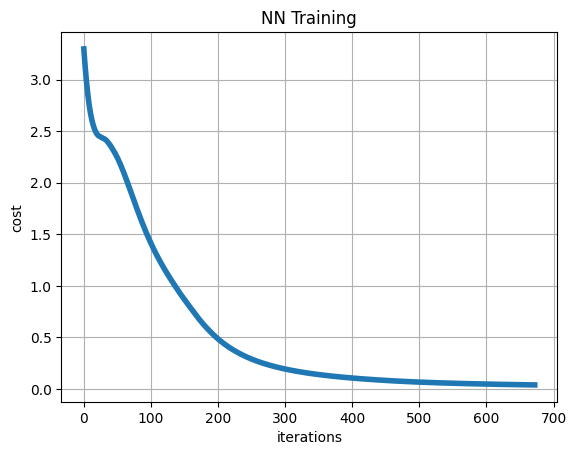

/tmp/ipykernel_3547/3974756554.py:259: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(data, 'RGB')


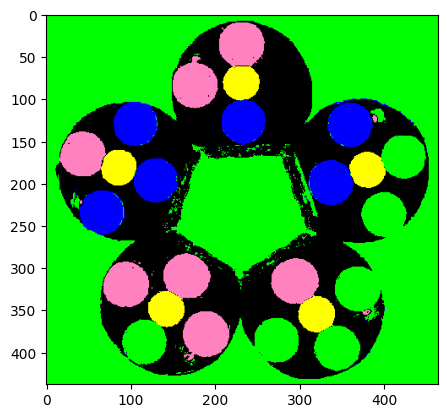

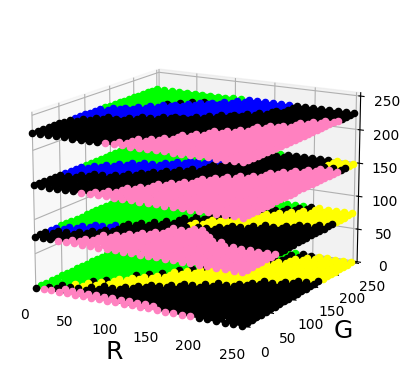

In [4]:
NN(path_dat,
    TRAINING_SET_BK = 1,
    TRAINING_SET_P = 1,
    TRAINING_SET_Y = 1,
    TRAINING_SET_G = 1,
    TRAINING_SET_B = 1,
    VALIDATION_STOP = False)


The __training__ with an __insufficient number of examples__ :
   * Tends to be very fast (the network will easily converge to a set of synaptic weights);
   * If the training is not early terminated, the __training error__ typically converges to zero. However, this is not synonym of a successful training;
   * The __generalization__ power of the network is significantly reduced. In other words, examples in the training set will be correctly classifiyed, but the NN is not capable to guarantee that points that are not present in the training set will be correctly classifyed.

### 2.3. Validation error

Now lets enable the __early stop__ based on the validation error (VALIDATION_STOP = True). The validation process will use 10% of the training examples.

Iteration 1, loss = 3.39067677
Validation score: 0.400000
Iteration 2, loss = 3.30001186
Validation score: 0.400000
Iteration 3, loss = 3.21514110
Validation score: 0.400000
Iteration 4, loss = 3.13523099
Validation score: 0.400000
Iteration 5, loss = 3.05843082
Validation score: 0.400000
Iteration 6, loss = 2.98807716
Validation score: 0.400000
Iteration 7, loss = 2.92530060
Validation score: 0.400000
Iteration 8, loss = 2.86909349
Validation score: 0.400000
Iteration 9, loss = 2.81721420
Validation score: 0.400000
Iteration 10, loss = 2.76958626
Validation score: 0.000000
Iteration 11, loss = 2.72775648
Validation score: 0.000000
Iteration 12, loss = 2.69086251
Validation score: 0.000000
Validation score did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.


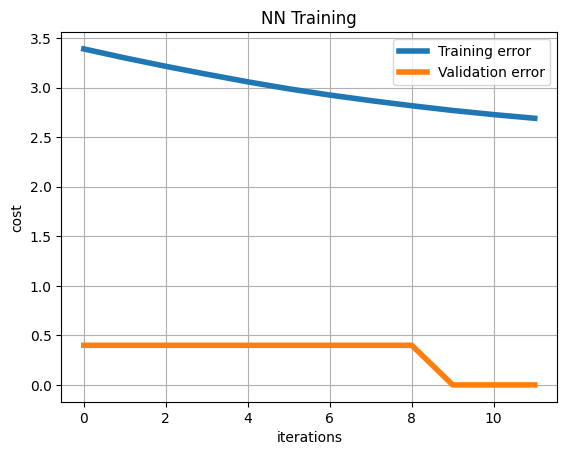

/tmp/ipykernel_3547/3974756554.py:259: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(data, 'RGB')


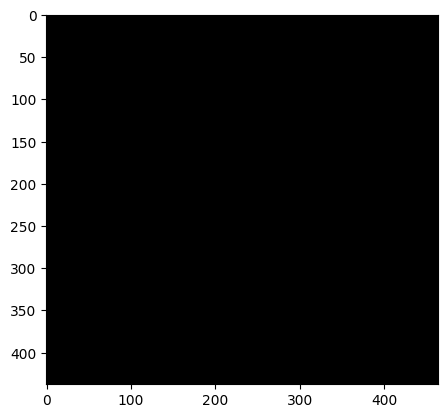

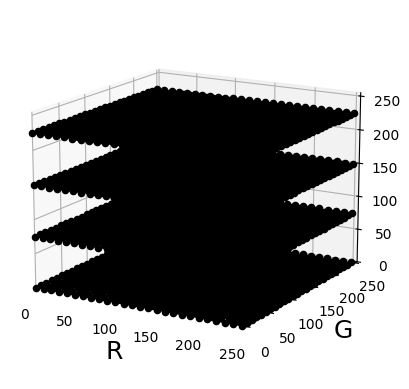

In [5]:
NN(path_dat,
    TRAINING_SET_BK = 10,
    TRAINING_SET_P = 10,
    TRAINING_SET_Y = 10,
    TRAINING_SET_G = 10,
    TRAINING_SET_B = 10,
    VALIDATION_STOP = True,
    VALIDATION_FRACTION = 0.1)

When using the __early stop__ mechanism, the training is terminated after a few steps since the __validation error__ (that measures the network __generalization__) is not cappable to improve.

### 2.4. Increasing the number of examples

In this example, let's increase to 20 (twenty) the number of examples of each class present in the __training set__.

Iteration 1, loss = 3.33137857
Validation score: 0.300000
Iteration 2, loss = 3.23504397
Validation score: 0.300000
Iteration 3, loss = 3.14647673
Validation score: 0.300000
Iteration 4, loss = 3.06425502
Validation score: 0.300000
Iteration 5, loss = 2.98742079
Validation score: 0.300000
Iteration 6, loss = 2.91786857
Validation score: 0.000000
Iteration 7, loss = 2.85460702
Validation score: 0.000000
Iteration 8, loss = 2.79646376
Validation score: 0.000000
Iteration 9, loss = 2.74312390
Validation score: 0.000000
Iteration 10, loss = 2.69593466
Validation score: 0.000000
Iteration 11, loss = 2.65482104
Validation score: 0.000000
Iteration 12, loss = 2.61847984
Validation score: 0.000000
Validation score did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.


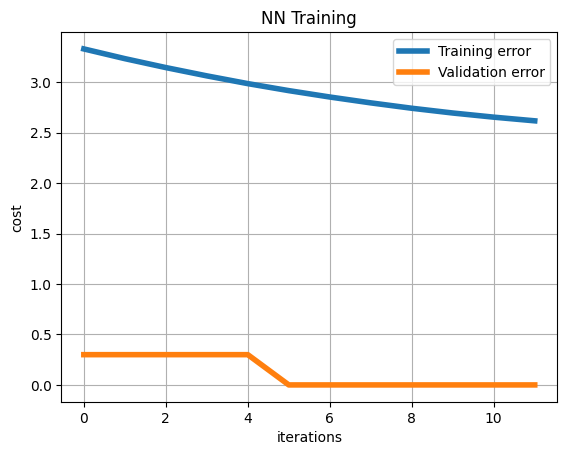

/tmp/ipykernel_3547/3974756554.py:259: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(data, 'RGB')


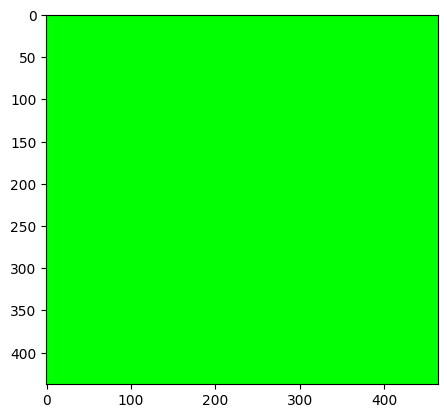

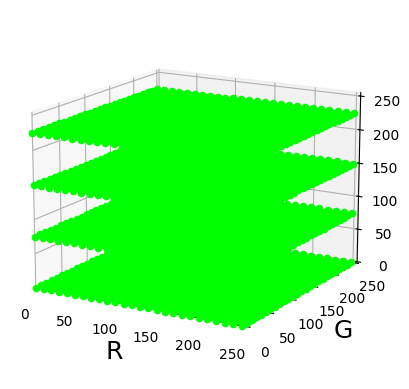

In [6]:
NN(path_dat,
    TRAINING_SET_BK = 20,
    TRAINING_SET_P = 20,
    TRAINING_SET_Y = 20,
    TRAINING_SET_G = 20,
    TRAINING_SET_B = 20,
    VALIDATION_STOP = True,
    VALIDATION_FRACTION = 0.1)

The number of examples in the training set yet does not represent the distribution of the pixels of each class in the image.

Now let's try with 500 examples in each class.

Iteration 1, loss = 2.96224885
Validation score: 0.000000
Iteration 2, loss = 2.50519214
Validation score: 0.000000
Iteration 3, loss = 2.42012947
Validation score: 0.000000
Iteration 4, loss = 2.35457668
Validation score: 0.000000
Iteration 5, loss = 2.26772771
Validation score: 0.000000
Iteration 6, loss = 2.16728972
Validation score: 0.000000
Iteration 7, loss = 2.04582937
Validation score: 0.000000
Iteration 8, loss = 1.90635516
Validation score: 0.196000
Iteration 9, loss = 1.75478188
Validation score: 0.196000
Iteration 10, loss = 1.59945535
Validation score: 0.196000
Iteration 11, loss = 1.44587769
Validation score: 0.368000
Iteration 12, loss = 1.31234419
Validation score: 0.672000
Iteration 13, loss = 1.19293308
Validation score: 0.776000
Iteration 14, loss = 1.08527757
Validation score: 0.776000
Iteration 15, loss = 0.99042235
Validation score: 0.780000
Iteration 16, loss = 0.90715495
Validation score: 0.788000
Iteration 17, loss = 0.83293743
Validation score: 0.828000
Iterat

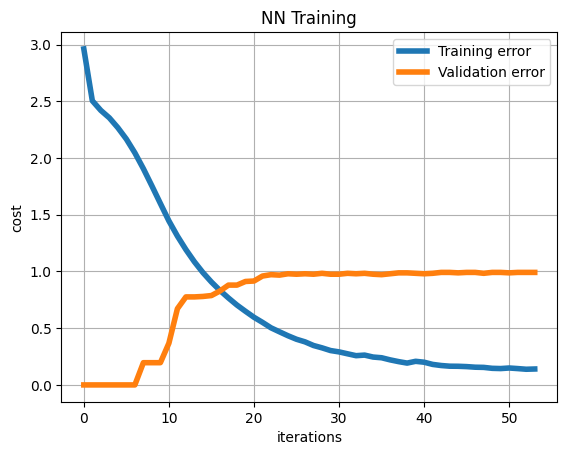

/tmp/ipykernel_3547/3974756554.py:259: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(data, 'RGB')


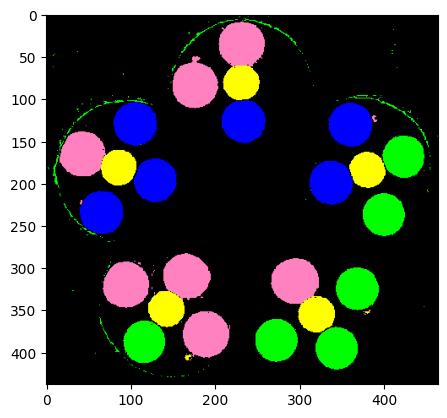

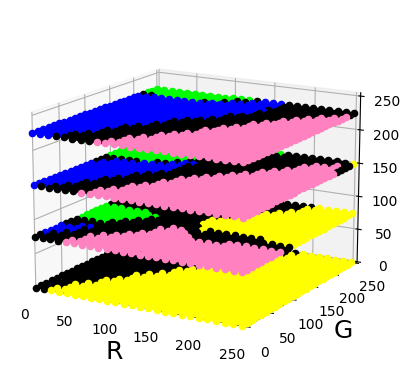

In [7]:
NN(path_dat,
    TRAINING_SET_BK = 500,
    TRAINING_SET_P = 500,
    TRAINING_SET_Y = 500,
    TRAINING_SET_G = 500,
    TRAINING_SET_B = 500,
    VALIDATION_STOP = True,
    VALIDATION_FRACTION = 0.1)

The number of examples is now representative enought for some classes, but not for all (BK: 0.3%, P: 4%, Y:8.8%, G-B: 4.6%). Some boudaries are not yet well defined.

### 2.5. Adjsuting input data distribution

Now let's use 10% of the examples of each class in the __training set__. Classes with more instances will have more training examples.

Iteration 1, loss = 1.57965994
Validation score: 0.818987
Iteration 2, loss = 1.04416477
Validation score: 0.787506
Iteration 3, loss = 0.70140440
Validation score: 0.780620
Iteration 4, loss = 0.62507414
Validation score: 0.779636
Iteration 5, loss = 0.60522775
Validation score: 0.781604
Iteration 6, loss = 0.54989307
Validation score: 0.797836
Iteration 7, loss = 0.49081089
Validation score: 0.849975
Iteration 8, loss = 0.43208748
Validation score: 0.854402
Iteration 9, loss = 0.42208004
Validation score: 0.848992
Iteration 10, loss = 0.40745302
Validation score: 0.849484
Iteration 11, loss = 0.40346900
Validation score: 0.848500
Iteration 12, loss = 0.40571251
Validation score: 0.847516
Iteration 13, loss = 0.39987256
Validation score: 0.848008
Iteration 14, loss = 0.40021208
Validation score: 0.847516
Iteration 15, loss = 0.39554229
Validation score: 0.848008
Iteration 16, loss = 0.39294736
Validation score: 0.847024
Iteration 17, loss = 0.39359474
Validation score: 0.847516
Iterat

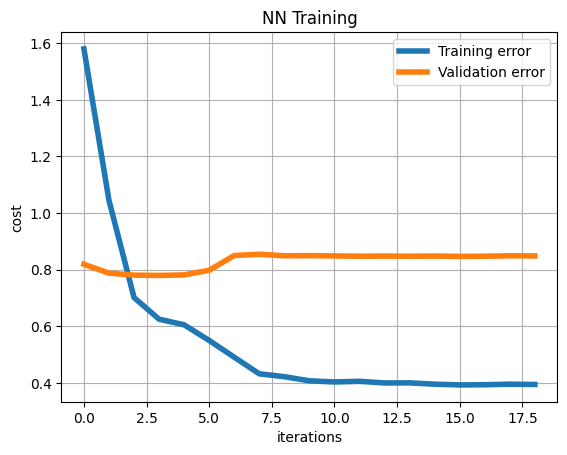

/tmp/ipykernel_3547/3974756554.py:259: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(data, 'RGB')


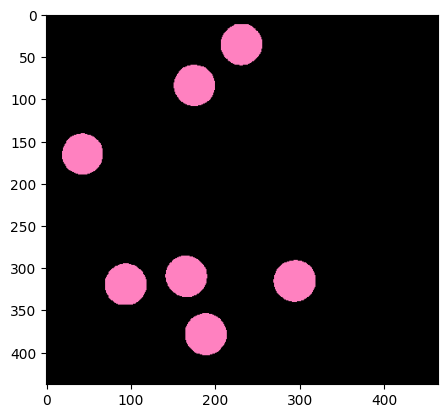

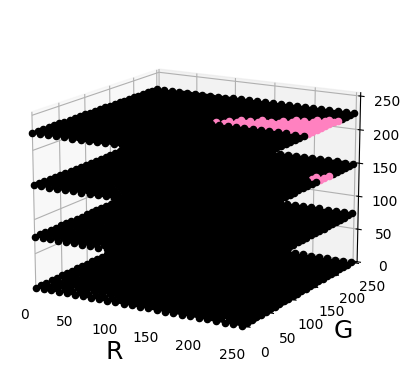

In [8]:
NN(path_dat,
    TRAINING_SET_BK = 16345,
    TRAINING_SET_P = 1256,
    TRAINING_SET_Y = 567,
    TRAINING_SET_G = 1077,
    TRAINING_SET_B = 1077,
    VALIDATION_STOP = True,
    VALIDATION_FRACTION = 0.1)

Now let's try 20%...

Iteration 1, loss = 1.40648926
Validation score: 0.808364
Iteration 2, loss = 0.92954036
Validation score: 0.788930
Iteration 3, loss = 0.63295772
Validation score: 0.869619
Iteration 4, loss = 0.35506886
Validation score: 0.893727
Iteration 5, loss = 0.25992441
Validation score: 0.973186
Iteration 6, loss = 0.20872121
Validation score: 0.972694
Iteration 7, loss = 0.18736329
Validation score: 0.971710
Iteration 8, loss = 0.17690344
Validation score: 0.974416
Iteration 9, loss = 0.17579224
Validation score: 0.971710
Iteration 10, loss = 0.17306557
Validation score: 0.971710
Iteration 11, loss = 0.17514301
Validation score: 0.972940
Iteration 12, loss = 0.16876510
Validation score: 0.965068
Iteration 13, loss = 0.16563463
Validation score: 0.973432
Iteration 14, loss = 0.16567281
Validation score: 0.972448
Iteration 15, loss = 0.16323033
Validation score: 0.975400
Iteration 16, loss = 0.16280912
Validation score: 0.971956
Iteration 17, loss = 0.16277936
Validation score: 0.973186
Iterat

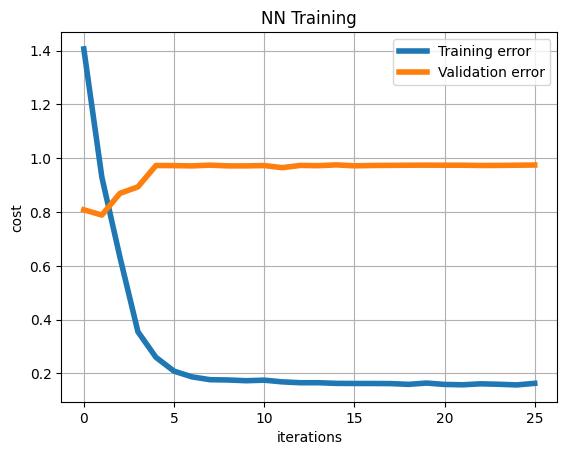

/tmp/ipykernel_3547/3974756554.py:259: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(data, 'RGB')


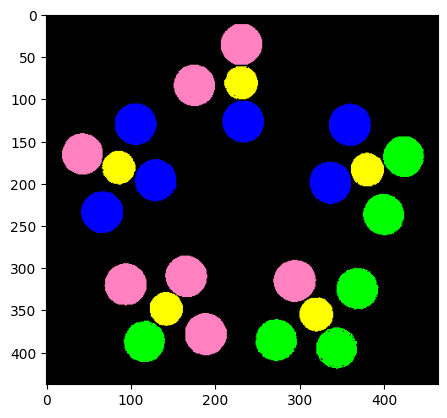

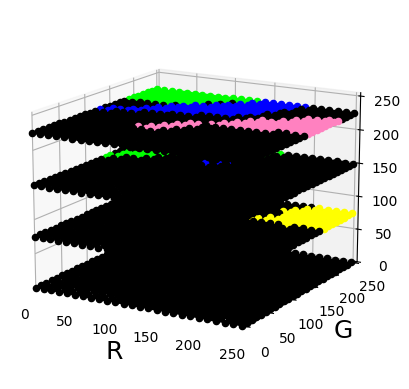

In [9]:
NN(path_dat,
    TRAINING_SET_BK = 32690,
    TRAINING_SET_P = 2512,
    TRAINING_SET_Y = 1134,
    TRAINING_SET_G = 2154,
    TRAINING_SET_B = 2154,
    VALIDATION_STOP = True,
    VALIDATION_FRACTION = 0.1)

General rule: __The more training examples, the better the network performance!!!__

### 2.6. Influence of the learning rate

Now let's check the influence of the learning rate changing the default value ($\eta = 0.005$) to a higher value ($\eta = 0.1$)...


Iteration 1, loss = 1.29645873
Validation score: 0.795572
Iteration 2, loss = 1.27198131
Validation score: 0.795572
Iteration 3, loss = 1.27172681
Validation score: 0.795572
Iteration 4, loss = 1.27483550
Validation score: 0.795572
Iteration 5, loss = 1.27134120
Validation score: 0.795572
Iteration 6, loss = 1.27350554
Validation score: 0.795572
Iteration 7, loss = 1.27301672
Validation score: 0.795572
Iteration 8, loss = 1.27287446
Validation score: 0.795572
Iteration 9, loss = 1.27485158
Validation score: 0.795572
Iteration 10, loss = 1.27289005
Validation score: 0.795572
Iteration 11, loss = 1.27289331
Validation score: 0.795572
Iteration 12, loss = 1.27464348
Validation score: 0.795572
Validation score did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.


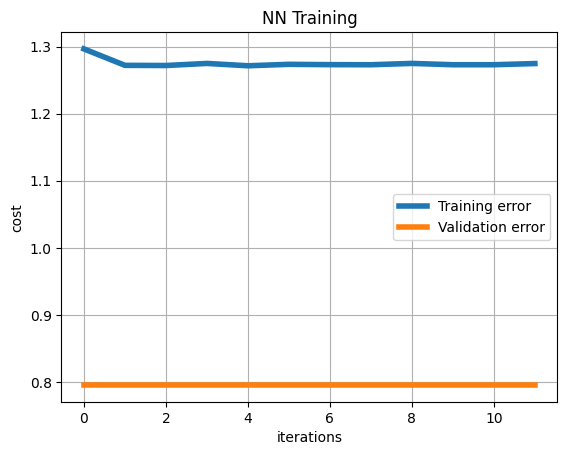

/tmp/ipykernel_3547/3974756554.py:259: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(data, 'RGB')


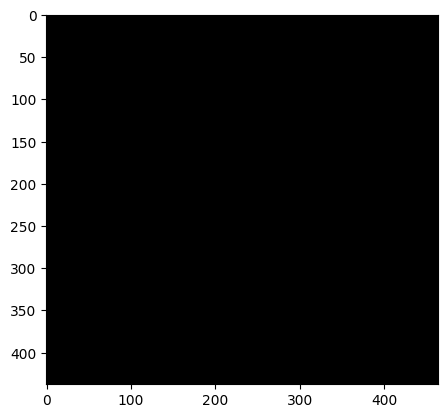

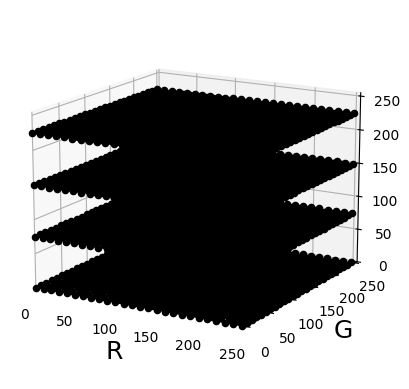

In [10]:
NN(path_dat,
    TRAINING_SET_BK = 32690,
    TRAINING_SET_P = 2512,
    TRAINING_SET_Y = 1134,
    TRAINING_SET_G = 2154,
    TRAINING_SET_B = 2154,
    LEARNING_RATE = 0.1,
    VALIDATION_STOP = True,
    VALIDATION_FRACTION = 0.1)

A __high learning rate__ does not assure the network convergence!!

Now let's try a __low learning rate__ ($\eta = 0.0001$). In this case, since the training error has a small variation in each iteration, let's increase N_STEPS_STOP to avoid early stop due to the small variation of the validation error.

Iteration 1, loss = 3.74302008
Validation score: 0.028290
Iteration 2, loss = 3.13557212
Validation score: 0.000000
Iteration 3, loss = 2.62848896
Validation score: 0.000000
Iteration 4, loss = 2.23574567
Validation score: 0.804428
Iteration 5, loss = 1.93491994
Validation score: 0.804428
Iteration 6, loss = 1.70869812
Validation score: 0.804428
Iteration 7, loss = 1.56091925
Validation score: 0.804428
Iteration 8, loss = 1.45787072
Validation score: 0.804428
Iteration 9, loss = 1.39014864
Validation score: 0.804428
Iteration 10, loss = 1.34800640
Validation score: 0.804428
Iteration 11, loss = 1.31938621
Validation score: 0.804428
Iteration 12, loss = 1.29961769
Validation score: 0.804428
Iteration 13, loss = 1.28570445
Validation score: 0.804428
Iteration 14, loss = 1.27571858
Validation score: 0.804428
Iteration 15, loss = 1.26830970
Validation score: 0.804428
Iteration 16, loss = 1.26264599
Validation score: 0.804428
Iteration 17, loss = 1.25814299
Validation score: 0.804428
Iterat

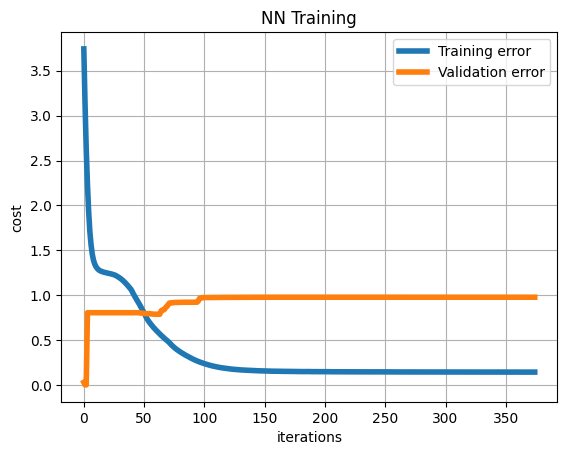

/tmp/ipykernel_3547/3974756554.py:259: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(data, 'RGB')


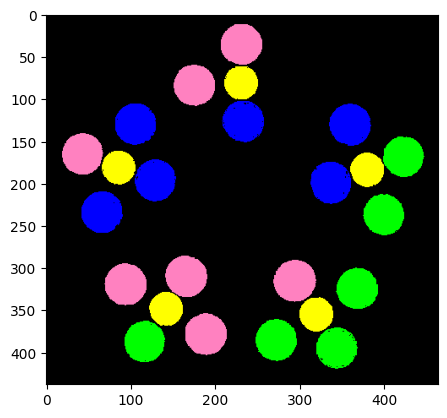

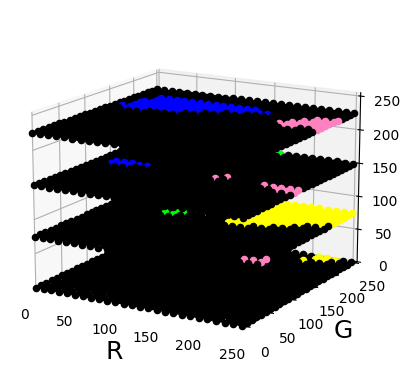

In [11]:
NN(path_dat,
    TRAINING_SET_BK = 32690,
    TRAINING_SET_P = 2512,
    TRAINING_SET_Y = 1134,
    TRAINING_SET_G = 2154,
    TRAINING_SET_B = 2154,
    LEARNING_RATE = 0.0001,
    VALIDATION_STOP = True,
    VALIDATION_FRACTION = 0.1,
    N_STEPS_STOP = 100)

Using a __low learning rate__, the training becomes very slow.

### 2.7. Underfitting

In this test, let's change the number of neurons in the hidden layer from 20 (default) to 3.

Iteration 1, loss = 3.21401600
Validation score: 0.000000
Iteration 2, loss = 2.43708125
Validation score: 0.801722
Iteration 3, loss = 1.83978402
Validation score: 0.801722
Iteration 4, loss = 1.48715479
Validation score: 0.801722
Iteration 5, loss = 1.36059213
Validation score: 0.801722
Iteration 6, loss = 1.31034743
Validation score: 0.801722
Iteration 7, loss = 1.28733610
Validation score: 0.801722
Iteration 8, loss = 1.27573612
Validation score: 0.801722
Iteration 9, loss = 1.26951968
Validation score: 0.801722
Iteration 10, loss = 1.26598141
Validation score: 0.801722
Iteration 11, loss = 1.26384883
Validation score: 0.801722
Iteration 12, loss = 1.26242938
Validation score: 0.801722
Iteration 13, loss = 1.26138285
Validation score: 0.801722
Validation score did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.


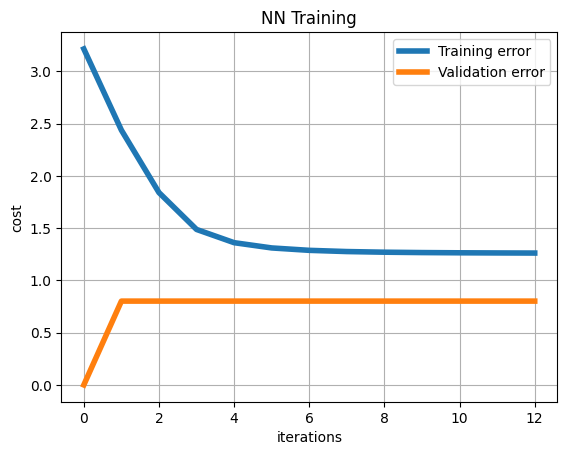

/tmp/ipykernel_3547/3974756554.py:259: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(data, 'RGB')


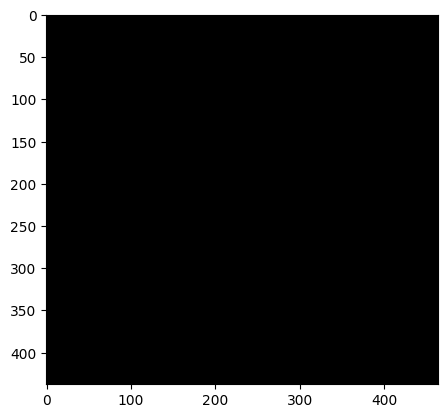

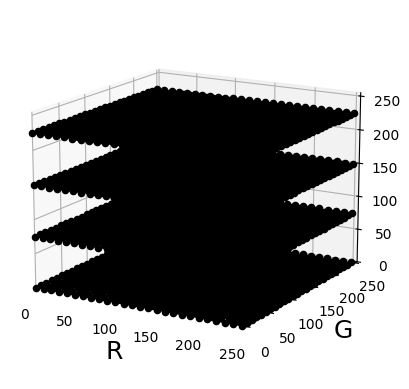

In [12]:
NN(path_dat,
    TRAINING_SET_BK = 32690,
    TRAINING_SET_P = 2512,
    TRAINING_SET_Y = 1134,
    TRAINING_SET_G = 2154,
    TRAINING_SET_B = 2154,
    NUM_NEURONS_HIDDEN = 3,
    LEARNING_RATE = 0.001,
    VALIDATION_STOP = True,
    VALIDATION_FRACTION = 0.1)

Although typically the training and validation errors decreased, with a __small number of neurons__ in the hidden layer, the network __representation power is too small__. This is a __underfitting__ condition. It is not cappable to represent complex concepts.

Now let's try a NN with 50 neurons in the hidden layer.


Iteration 1, loss = 1.51247793
Validation score: 0.817712
Iteration 2, loss = 0.98507932
Validation score: 0.802460
Iteration 3, loss = 0.64147871
Validation score: 0.779336
Iteration 4, loss = 0.43759553
Validation score: 0.892497
Iteration 5, loss = 0.32062262
Validation score: 0.968512
Iteration 6, loss = 0.25759177
Validation score: 0.971710
Iteration 7, loss = 0.22090038
Validation score: 0.972940
Iteration 8, loss = 0.19854514
Validation score: 0.972202
Iteration 9, loss = 0.18510866
Validation score: 0.972448
Iteration 10, loss = 0.17671690
Validation score: 0.972448
Iteration 11, loss = 0.17011098
Validation score: 0.971710
Iteration 12, loss = 0.16687873
Validation score: 0.974170
Iteration 13, loss = 0.16264254
Validation score: 0.972940
Iteration 14, loss = 0.16146608
Validation score: 0.972448
Iteration 15, loss = 0.15968258
Validation score: 0.971956
Iteration 16, loss = 0.15671204
Validation score: 0.973186
Iteration 17, loss = 0.15620283
Validation score: 0.973924
Iterat

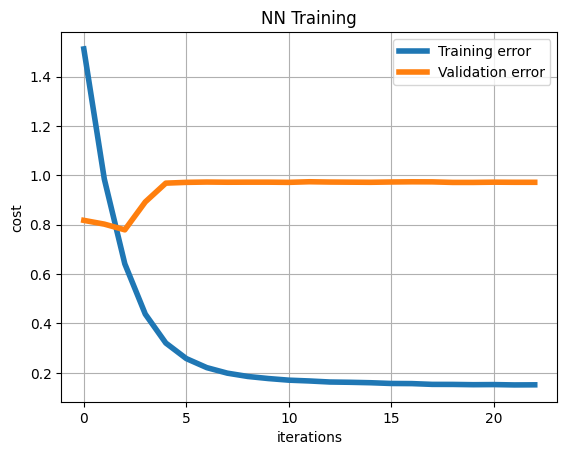

/tmp/ipykernel_3547/3974756554.py:259: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(data, 'RGB')


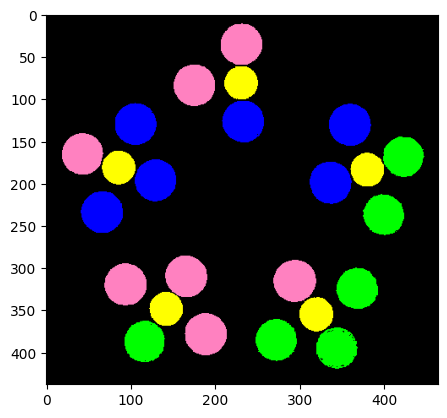

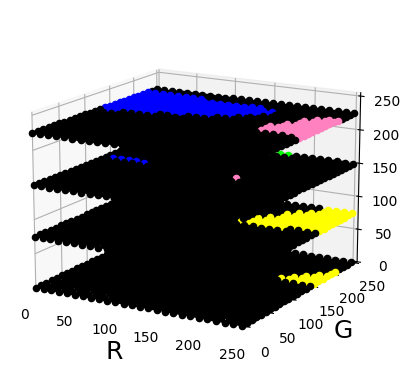

In [13]:
NN(path_dat,
    TRAINING_SET_BK = 32690,
    TRAINING_SET_P = 2512,
    TRAINING_SET_Y = 1134,
    TRAINING_SET_G = 2154,
    TRAINING_SET_B = 2154,
    NUM_NEURONS_HIDDEN = 50,
    LEARNING_RATE = 0.001,
    VALIDATION_STOP = True,
    VALIDATION_FRACTION = 0.1)

With a __high number of neurons__, the network has an icreased capacity to represent complex concepts. However, training and use of the NN require much more __computational power__ (memory, processor, time...).


### 2.8. Increasing the validation set

The more we increase the number of validation examples (without reduciont the number of training examples), the better we can evaluate the network generalization.

Iteration 1, loss = 1.47194131
Validation score: 0.801201
Iteration 2, loss = 1.16937949
Validation score: 0.801201
Iteration 3, loss = 0.78188019
Validation score: 0.781616
Iteration 4, loss = 0.45606544
Validation score: 0.841157
Iteration 5, loss = 0.34373492
Validation score: 0.919299
Iteration 6, loss = 0.29406709
Validation score: 0.973329
Iteration 7, loss = 0.23545457
Validation score: 0.974018
Iteration 8, loss = 0.20447325
Validation score: 0.975002
Iteration 9, loss = 0.19283201
Validation score: 0.966932
Iteration 10, loss = 0.18938716
Validation score: 0.975691
Iteration 11, loss = 0.18131278
Validation score: 0.974215
Iteration 12, loss = 0.17619193
Validation score: 0.976085
Iteration 13, loss = 0.17765159
Validation score: 0.953253
Iteration 14, loss = 0.20333097
Validation score: 0.974215
Iteration 15, loss = 0.17517280
Validation score: 0.974314
Iteration 16, loss = 0.17481030
Validation score: 0.972640
Iteration 17, loss = 0.16994266
Validation score: 0.974609
Iterat

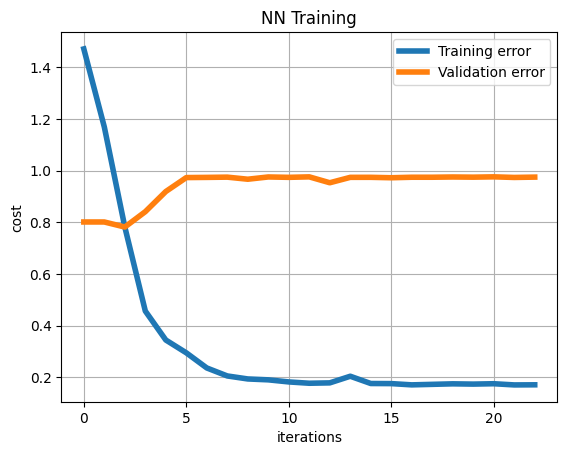

/tmp/ipykernel_3547/3974756554.py:259: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(data, 'RGB')


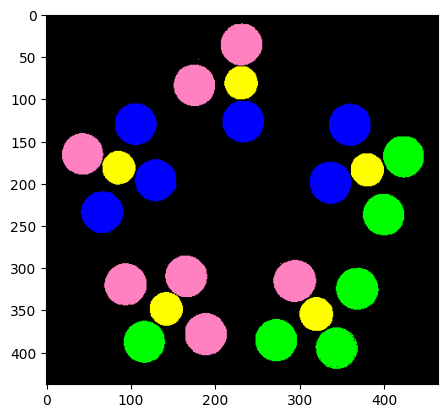

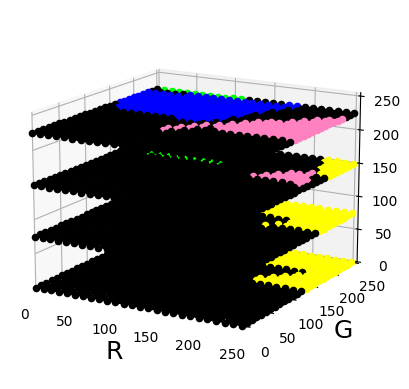

In [14]:
NN(path_dat,
    TRAINING_SET_BK = 32690,
    TRAINING_SET_P = 2512,
    TRAINING_SET_Y = 1134,
    TRAINING_SET_G = 2154,
    TRAINING_SET_B = 2154,
    VALIDATION_STOP = True,
    VALIDATION_FRACTION = 0.25)

____
<center>
<img src="https://upload.wikimedia.org/wikipedia/commons/0/0a/Logo_Unesp.svg" width="400" style="float: left; margin-right: 5px;" border="0px" />
</center>